Data Preparation

In [43]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
Step 1 : Read the File

In [7]:
df=pd.read_excel(r"C:\Users\user\Downloads\Medical_Inventory_Masked.xlsx")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14218 entries, 0 to 14217
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Typeofsales     14218 non-null  object 
 1   Patient_ID      14218 non-null  float64
 2   Specialisation  14218 non-null  object 
 3   Dept            14218 non-null  object 
 4   Dateofbill      14218 non-null  object 
 5   Quantity        14218 non-null  float64
 6   ReturnQuantity  14218 non-null  float64
 7   Final_Cost      14218 non-null  float64
 8   Final_Sales     14218 non-null  float64
 9   RtnMRP          14218 non-null  float64
 10  Formulation     13565 non-null  object 
 11  DrugName        12550 non-null  object 
 12  SubCat          12550 non-null  object 
 13  SubCat1         12526 non-null  object 
dtypes: float64(6), object(8)
memory usage: 1.5+ MB


Step 2 : TypeCasting

In [10]:
df["Patient_ID"]=df["Patient_ID"].astype("object")
df["Dateofbill"]=df["Dateofbill"].astype("datetime64[ns]")

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14218 entries, 0 to 14217
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Typeofsales     14218 non-null  object        
 1   Patient_ID      14218 non-null  object        
 2   Specialisation  14218 non-null  object        
 3   Dept            14218 non-null  object        
 4   Dateofbill      14218 non-null  datetime64[ns]
 5   Quantity        14218 non-null  float64       
 6   ReturnQuantity  14218 non-null  float64       
 7   Final_Cost      14218 non-null  float64       
 8   Final_Sales     14218 non-null  float64       
 9   RtnMRP          14218 non-null  float64       
 10  Formulation     13565 non-null  object        
 11  DrugName        12550 non-null  object        
 12  SubCat          12550 non-null  object        
 13  SubCat1         12526 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(8)
memory usa

Step 3 : Find Duplicates and Treating the Duplicates

In [12]:
df.duplicated().sum()

np.int64(0)

 Step 4 : Null Value Imputation

In [13]:
from sklearn.impute import SimpleImputer

In [14]:
df.isnull().sum()

Typeofsales          0
Patient_ID           0
Specialisation       0
Dept                 0
Dateofbill           0
Quantity             0
ReturnQuantity       0
Final_Cost           0
Final_Sales          0
RtnMRP               0
Formulation        653
DrugName          1668
SubCat            1668
SubCat1           1692
dtype: int64

In [15]:
from sklearn.impute import SimpleImputer

In [16]:
var=SimpleImputer(missing_values=np.nan,strategy='most_frequent')

In [17]:
df["Formulation"]=pd.DataFrame(var.fit_transform(df[["Formulation"]]))

In [40]:
df.isnull().sum()

Typeofsales          0
Patient_ID           0
Specialisation       0
Dept                 0
Dateofbill           0
Quantity             0
ReturnQuantity       0
Final_Cost           0
Final_Sales          0
RtnMRP               0
Formulation          0
DrugName          1668
SubCat            1668
SubCat1           1692
dtype: int64

In [18]:
df[["DrugName","SubCat","SubCat1"]] = df[["DrugName","SubCat","SubCat1"]].ffill()

In [46]:
df.isnull().sum()

Typeofsales       0
Patient_ID        0
Specialisation    0
Dept              0
Dateofbill        0
Quantity          0
ReturnQuantity    0
Final_Cost        0
Final_Sales       0
RtnMRP            0
Formulation       0
DrugName          0
SubCat            0
SubCat1           0
dtype: int64

Step 5 : Outlier Detection

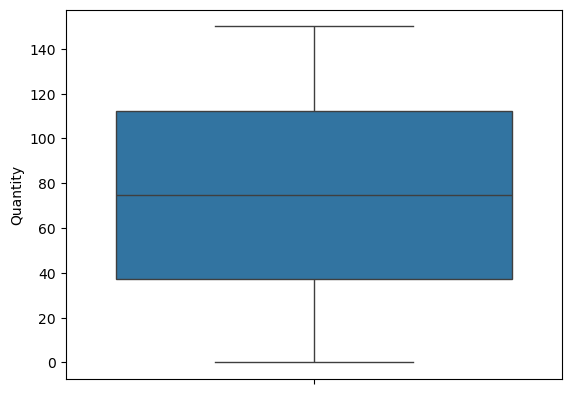

In [26]:
sns.boxplot(df.Quantity)
plt.show()

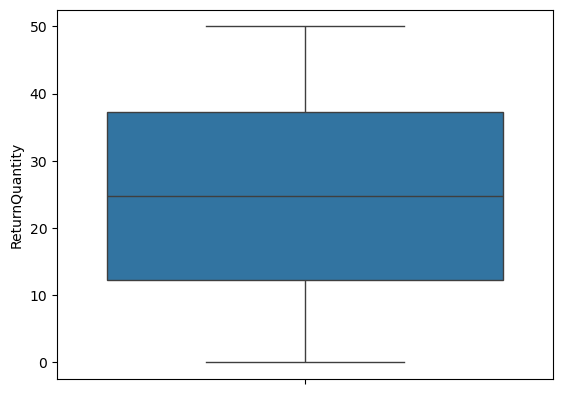

In [27]:
sns.boxplot(df.ReturnQuantity)
plt.show()

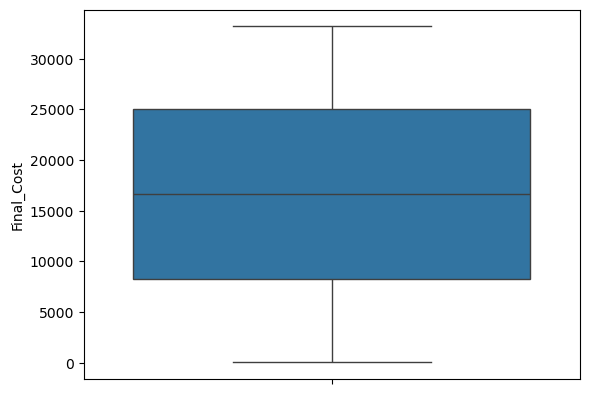

In [28]:
sns.boxplot(df.Final_Cost)
plt.show()

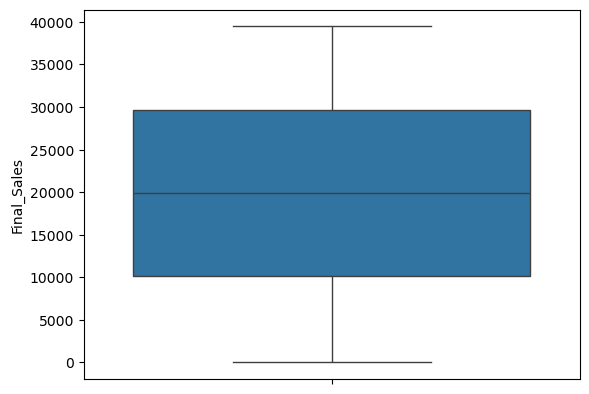

In [29]:

sns.boxplot(df.Final_Sales)
plt.show()

In [19]:
from feature_engine.outliers import Winsorizer

In [20]:
Iqr=Winsorizer(capping_method='iqr',tail='both',fold=1.5,variables=['Final_Sales','ReturnQuantity','Final_Cost','RtnMRP','Quantity'])

In [21]:
df[['Final_Sales','Quantity','ReturnQuantity','Final_Cost','RtnMRP']]=Iqr.fit_transform(df[['Final_Sales','Quantity','ReturnQuantity','Final_Cost','RtnMRP']])

In [22]:
df["Range of Qauntity"]=pd.cut(df["Quantity"],bins=[0,40,74,150],labels=["Low Quantity","Mediun Quantity","High Quantity"],include_lowest=True)

In [25]:

df["Range of ReturnQuantity"]=pd.cut(df["ReturnQuantity"],bins=[0,12,24,50],labels=["Low Quantity","Mediun Quantity","High Quantity"],include_lowest=True)

In [28]:
df["Range of Final_Cost"]=pd.cut(df["Final_Cost"],bins=[48,8000,16619,34000],labels=["Low Fina Cost","Mediun Fina Cost"," High Fina Cost"],include_lowest=True)

In [31]:
df["Range of Final_Sales"]=pd.cut(df["Final_Sales"],bins=[1,8000,19816,40000],labels=["Low Sale","Mediun Sale"," High Sale"],include_lowest=True)

In [33]:
df["Range of RtnMRP"]=pd.cut(df["RtnMRP"],bins=[0,1500,4011,8013],labels=["Low RtnMRP","Mediun RtnMRP"," High RtnMRP"],include_lowest=True)

Step 6 : Encoding

Label Encodidng

In [37]:
from sklearn.preprocessing import LabelEncoder


In [38]:
label=LabelEncoder()

In [40]:
df["Dept"]=label.fit_transform(df["Dept"])

In [42]:
df["Specialisation"]=label.fit_transform(df["Specialisation"])


Step 7 :Transfering file from Jupyter to Excel

In [45]:


df.to_excel("Clean_Data.xlsx", index=False)

In [46]:
import os
os.getcwd()

'C:\\Users\\user'